<a href="https://colab.research.google.com/github/perarneskjelvik/Selvstudium/blob/main/Funksjon_Xi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Funksjon Xi2

Forfatter: Per Arne Skjelvik

Dato: 19.2.2026

##Formål
Denne notebooken inneholder kode som bruker nevrale nettverk for å lære X^2-funksjonen.

In [15]:

# importerer nødvendige bibliotek


import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.metrics import Recall, Precision, AUC
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, TensorBoard, EarlyStopping
import random
import matplotlib.pyplot as plt



In [16]:

# Treningsdata X^2-funksjon
x = []
y = []

# lager en tabell med 10000 treningsdata
# lar x variere mellom 0 og 50
# beregner ikke y for x=2 og x= 4 (testdata)

for i in range(0,10000):
    xi = random.randint(0,5000)
    xi = xi/100
    if(xi==2.0 or xi==4.0):
        continue
    yi = xi**2
    x.append([xi])
    y.append(yi)




In [ ]:
# Viser noen av testdataene

print(np.array(x)[0:20])



In [ ]:
# Setter seed for random.
# Får da samme beregning av vekter hver gang vi kjører koden.

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


# Definerer lagene/strukturen i modellen


# Nettverket er sekvensielt, dvs hvert lag sender output direkte til neste lag.
model_v2 = tf.keras.models.Sequential()

# Definerer input layer som har 1 input
model_v2.add(tf.keras.Input(shape=(1,)))

# Legger til 3 ekstra skjulte lag
model_v2.add(tf.keras.layers.Dense(units=16, activation="relu"))
model_v2.add(tf.keras.layers.Dense(units=16, activation="relu"))
model_v2.add(tf.keras.layers.Dense(units=8, activation="relu"))

# Definerer output layer som har kun 1 node/output
# Bruker linear som aktiveringsfunksjon
model_v2.add(tf.keras.layers.Dense(units=1, activation='linear'))

print("Oppsummering av den nye modellen:")
print("")
print(model_v2.summary())
print("")

# Kompilerer den nye modellen
model_v2.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.MeanSquaredError())


#Trener den nye modellen

print("Trener den nye modellen...")
model_v2.fit(np.array(x), np.array(y),
          batch_size=256, epochs=500)
print("Trening av den nye modellen fullført.")




Tester den nye modellen:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[[100.48837]
 [399.55118]]
Fasit:
100
400
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


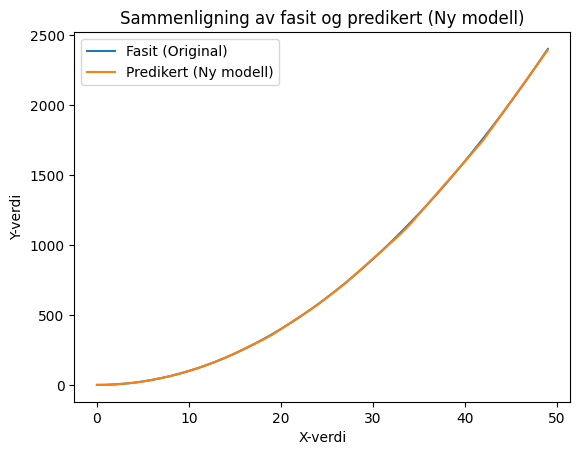

In [19]:
# Tester den nye modellen
print("Tester den nye modellen:")
q_v2 = model_v2.predict( np.array( [[10],[20]] )  )
print(q_v2)

# Fasit
print("Fasit:")
print("100")
print("400")

# Plotting results for the new model
plt.figure()
plt.plot(original, label='Fasit (Original)')
predicted_v2 = model_v2.predict(np.array([ x for x in range(0,50) ]).reshape(-1, 1))
plt.plot(predicted_v2, label='Predikert (Ny modell)')
plt.title('Sammenligning av fasit og predikert (Ny modell)')
plt.xlabel('X-verdi')
plt.ylabel('Y-verdi')
plt.legend()
plt.show()